# Hate Speech Detection during the 2022 Ecuador Strike

Portfolio version of the code associated with the published conference paper **“Hate Speech Detection on Twitter: A Machine Learning Approach to Identify Attacks on Indigenous People During the 2022 Ecuador Strike.”**

This notebook focuses on the reproducible local pipeline represented in the supplied code: exploratory analysis, class balancing, TF-IDF features, Multinomial Naive Bayes classification, Spanish text preprocessing, and evaluation.

> **Data note:** the original tweet-level dataset is not distributed in this public portfolio repository. Place an authorized copy at `data/hate_speech_tweets.csv` to rerun the analysis. Aggregate results are retained where they are supported by the saved notebook outputs and published paper.

> **Research note:** the published paper also reports a second experiment using Google Perspective API verification. That experiment is documented in the paper, but the supplied notebook does not contain the Perspective API implementation, so it is not presented here as executable code.


#Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import requests
csv_file_path = "../data/hate_speech_tweets.csv"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)
print(f"The shape of the dataset is: {df.shape}")


#Bar plot

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
def plot_is_hate_distribution(df):
    df.rename(columns={'is_hate?\n1=SI\n0=NO\nX=verificar': 'is_hate'}, inplace=True)
    # Contar la cantidad de ocurrencias de cada valor en la columna "is_hate"
    value_counts = df['is_hate'].value_counts()

    print(value_counts.index)
    # Crear la gráfica de barras
    plt.bar(value_counts.index, value_counts.values)

    # Etiquetas de los ejes y título de la gráfica
    plt.xlabel('Labels')
    plt.ylabel('Tweets')
    plt.title(f'Total values of initial Tweets: {df.shape[0]}')
    for i, v in enumerate(value_counts.values):
        plt.text(i, v, str(v), ha='center', va='bottom')
    # Save
    plt.savefig('BarPlot.svg', format='svg')
    # Mostrar la gráfica
    plt.show()
plot_is_hate_distribution(df)


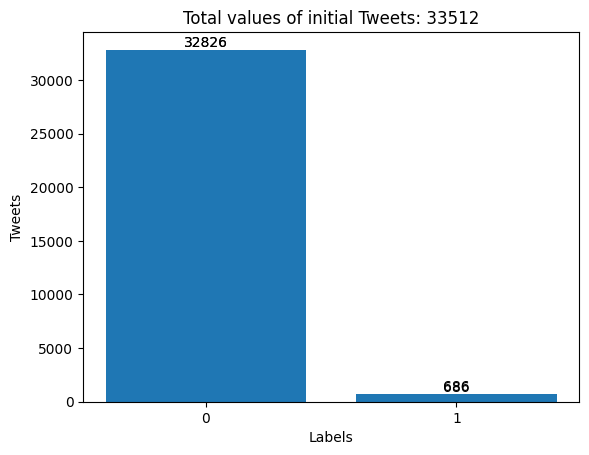

In [ ]:
import matplotlib.pyplot as plt

def plot_is_hate_distribution(df):
    #df.rename(columns={'is_hate?\n1=SI\n0=NO\nX=verificar': 'is_hate'}, inplace=True)
    # Contar la cantidad de ocurrencias de cada valor en la columna "is_hate"
    value_counts = df['is_hate'].value_counts()

    # Crear la gráfica de barras
    labels = ['0', '1']  # Etiquetas en el eje X
    #values = [value_counts.get(label, 0) for label in labels]  # Obtener los valores correspondientes
    values =  value_counts.values
    # Crear un rango de valores para el eje X
    x_range = range(len(labels))

    plt.bar(x_range, values, width=0.8)  # Ancho de la barra ajustado

    # Etiquetas de los ejes y título de la gráfica
    plt.xlabel('Labels')
    plt.ylabel('Tweets')
    plt.title(f'Total values of initial Tweets: {df.shape[0]}')  # Agregar el número de tweets al título
    plt.xticks(x_range, labels)  # Establecer las etiquetas en el eje X

    for i, v in enumerate(values):
        plt.text(x_range[i], v, str(v), ha='center', va='bottom')
        plt.text(x_range[i], v + 10, str(v), ha='center', va='bottom')  # Agregar el valor encima de la barra

    # Save
    plt.savefig('BarPlot3.svg', format='svg')

    # Mostrar la gráfica
    plt.show()

# Suponiendo que 'df' es tu DataFrame
plot_is_hate_distribution(df)


#Line Chart


In [ ]:
df_filtered = df[df['is_hate'].isin([1,0])]
df['created_at'] = pd.to_datetime(df['created_at'])

# Agrupar los tweets por día y contar la cantidad de tweets "hate" y "no hate" para cada día
tweets_por_dia = df.groupby([df['created_at'].dt.date, 'is_hate']).size().unstack(fill_value=0)
tweets_por_dia
#df_filtered


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir la columna "created_at" a formato de fecha
df['created_at'] = pd.to_datetime(df['created_at'])

# Agrupar los tweets por día y contar la cantidad de tweets "hate" y "no hate" para cada día
tweets_por_dia = df.groupby([df['created_at'].dt.date, 'is_hate']).size().unstack(fill_value=0)

# Calcular el total de tweets por día sumando las cantidades de "Hate" y "No Hate"
tweets_por_dia['Total'] = tweets_por_dia[1] + tweets_por_dia[0]

# Crear el gráfico de dispersión con líneas de conexión para el progreso de tweets por día
plt.plot(tweets_por_dia.index, tweets_por_dia[1], marker='o', label='Hate')
plt.plot(tweets_por_dia.index, tweets_por_dia[0], marker='o', label='No Hate', linestyle='dashed')

# Etiquetas de los ejes y título de la gráfica
plt.xlabel('Days during strike')
plt.ylabel('Tweets')
plt.title('Tweets progress: "Hate" and "No Hate" by day')

# Rotar las etiquetas del eje x para mejorar la legibilidad
plt.xticks(rotation=45)

# Mostrar la leyenda
plt.legend()

# Save plot
plt.savefig('Line_chart.svg', format='svg')

# Mostrar la gráfica
plt.tight_layout()
plt.show()


#Balance Dataset

In [ ]:
# Dividir el dataframe en dos grupos: tweets con etiqueta "hate" (1) y tweets con etiqueta "no hate" (0)
df_hate = df[df['is_hate'].isin([1])]
df_No_hate = df[df['is_hate'].isin([0])]

# Seleccionar una muestra aleatoria de tweets de cada grupo con el mismo número de elementos
num_samples = min(len(df_hate), len(df_No_hate))
hate_tweets_sample = df_hate.sample(n=num_samples, random_state=42)
no_hate_tweets_sample = df_No_hate.sample(n=num_samples, random_state=42)

# Combinar las muestras seleccionadas para obtener el dataframe balanceado
balanced_df = pd.concat([hate_tweets_sample, no_hate_tweets_sample])

# Ahora 'balanced_df' contiene un dataset balanceado con el mismo número de tweets etiquetados como "hate" y "no hate"


In [ ]:
plot_is_hate_distribution(balanced_df)


#Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el DataFrame en entrenamiento y testing
train_df, test_df = train_test_split(balanced_df, test_size=0.2,shuffle=True, random_state=42)

# Imprimir la información de los tamaños de los conjuntos de datos
print("Tamaño del conjunto de entrenamiento:", len(train_df))
print("Tamaño del conjunto de validación:", len(test_df))


In [ ]:
model_target = 'is_hate'
train_df[model_target].value_counts()


#Model

In [ ]:
  from sklearn.feature_extraction.text import TfidfVectorizer
  from sklearn.naive_bayes import MultinomialNB
  from sklearn.pipeline import make_pipeline

  model = make_pipeline(TfidfVectorizer(), MultinomialNB())   #Define model


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
# Reemplazar los valores nulos en el DataFrame
balanced_df = balanced_df.fillna('')  # Reemplazar los valores nulos con una cadena vacía

# Dividir el dataframe en conjuntos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split( balanced_df['text'], balanced_df['is_hate'], test_size=0.2,shuffle=True, random_state=42)

# Crear y entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de validación
y_pred = model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Test_Accuracy:", accuracy)


Test_Accuracy: 0.8478552278820375


#Metrics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
print(classification_report(y_test, y_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.79      0.83       724
           1       0.82      0.90      0.86       768

    accuracy                           0.85      1492
   macro avg       0.85      0.85      0.85      1492
weighted avg       0.85      0.85      0.85      1492

Test accuracy: 0.8478552278820375


#Confusion Matrix

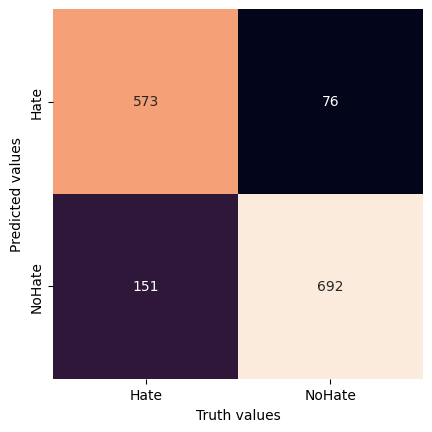

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión
mat = confusion_matrix(y_test, y_pred)

# Crear el mapa de calor de la matriz de confusión
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['Hate','NoHate'], yticklabels=['Hate','NoHate'])
plt.xlabel('Truth values')
plt.ylabel('Predicted values')
# Save plot
plt.savefig('ConfMatrix_SIN_TP.svg', format='svg')
plt.show()


#Above Model Using Text Preprocessing

#Text Preprocessing

#option 1

With new stop words

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from unidecode import unidecode
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_tweet(tweet):
    # Convertir el tweet a minúsculas
    tweet = tweet.lower()

    # Eliminar menciones (@usuario)
    tweet = re.sub(r'@\w+', '', tweet)

    # Eliminar hashtags (#hashtag)
    tweet = re.sub(r'#(\w+)', r'\1', tweet)

    # Eliminar enlaces (URLs)
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet)

    # Eliminar caracteres especiales y números
    tweet = re.sub(r'[^\w\s]', '', tweet)

    # Tokenización: convertir el tweet en una lista de palabras
    tokens = word_tokenize(tweet)

    # Eliminación de stopwords
    stop_words = set(stopwords.words('spanish'))
    # Agregar las nuevas palabras a la lista de stopwords
    new_stop_words = ["solo", "toda", "día", "paronacionalec2022", "paronacional",
                      "paronacionalec", "paronacionalecuador", "ahora", "bien", "si",
                      "mientras", "ser", "q", "cómo", "mismo", "hoy", "hacen", "van",
                      "año", "dicen", "siempre", "hace", "hacer", "puede", "vía", "aquí",
                      "así", "hecho","paronacional2022ec","dice","parte","favor","hora",
                      "ecuador","gente","paronacional2022","d", "decir","deben","siguen",
                      "va","ahí","vez","luego","seguir", "día", "ver"]
    stop_words.update(new_stop_words)

    tokens = [word for word in tokens if word not in stop_words]

    # Lematización (opcional): convertir las palabras a su forma base
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Unir las palabras procesadas para formar el tweet preprocesado
    preprocessed_tweet = ' '.join(tokens)

    return preprocessed_tweet


#Option2: without add new words to Stop Words

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from unidecode import unidecode
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


def preprocess_tweet(tweet):
    # Convertir el tweet a minúsculas
    tweet = tweet.lower()

    # Eliminar menciones (@usuario)
    tweet = re.sub(r'@\w+', '', tweet)

    # Eliminar hashtags (#hashtag)
    tweet = re.sub(r'#(\w+)', r'\1', tweet)

    # Eliminar enlaces (URLs)
    tweet = re.sub(r'http\S+|www\S+|https\S+', '', tweet)

    # Eliminar caracteres especiales y números
    tweet = re.sub(r'[^\w\s]', '', tweet)

    # Tokenización: convertir el tweet en una lista de palabras
    tokens = word_tokenize(tweet)

    # Eliminación de stopwords
    stop_words = set(stopwords.words('spanish'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematización (opcional): convertir las palabras a su forma base
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Unir las palabras procesadas para formar el tweet preprocesado
    preprocessed_tweet = ' '.join(tokens)

    return preprocessed_tweet


#Proof text processing function

In [ ]:
df['text'][849]


In [ ]:
preprocess_tweet(df['text'][849])


In [ ]:
balanced_df['preprocessed_text'] = balanced_df['text'].apply(preprocess_tweet)
balanced_df.head(5)


**WORD CLOUD**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

text = ' '.join(balanced_df['preprocessed_text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')
# Save plot
plt.savefig('Word_Cloud.svg', format='svg')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Reemplazar los valores nulos en el DataFrame
balanced_df = balanced_df.fillna('')  # Reemplazar los valores nulos con una cadena vacía

# Dividir el dataframe en conjuntos de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split( balanced_df['preprocessed_text'], balanced_df['is_hate'], test_size=0.2,shuffle=True, random_state=42)

# Crear y entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de validación
y_pred = model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print("Test_Accuracy:", accuracy)


Test_Accuracy: 0.8431635388739946


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
print(classification_report(y_test, y_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.78      0.83       724
           1       0.81      0.90      0.86       768

    accuracy                           0.84      1492
   macro avg       0.85      0.84      0.84      1492
weighted avg       0.85      0.84      0.84      1492

Test accuracy: 0.8431635388739946


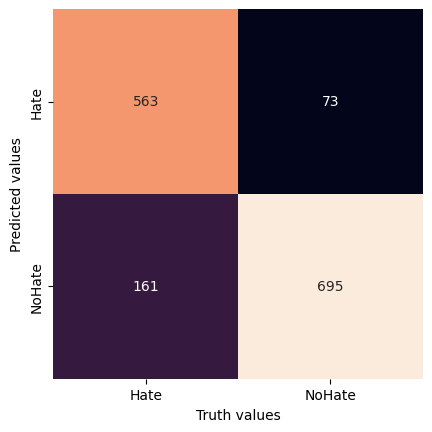

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de confusión
mat = confusion_matrix(y_test, y_pred)

# Crear el mapa de calor de la matriz de confusión
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['Hate','NoHate'], yticklabels=['Hate','NoHate'])
plt.xlabel('Truth values')
plt.ylabel('Predicted values')
# Save plot
plt.savefig('CongMatrix_TP.svg', format='svg')
plt.show()
